# Лабораторная работа №3

Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.

В этой работе используется датасет Pokémon из файлов `lr3/pokemon_complete.csv` и `lr3/pokemon_types.csv`.

## Описание задачи

Необходимо спрогнозировать базовый опыт Pokémon `base_experience` на основе боевых характеристик, физических параметров, поколения, редкости и информации о типах. Для расширения признакового пространства используется таблица `pokemon_types.csv`, которая описывает атакующие и защитные взаимодействия типов.

Задача является задачей регрессии. Для оценки качества используются метрики `MAE`, `RMSE` и `R2`. В подборе параметров применяются `GridSearchCV`, `RandomizedSearchCV` и `KFold`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

%matplotlib inline
sns.set(style='ticks')
RANDOM_STATE = 42

## Загрузка данных

Основная таблица содержит характеристики отдельных Pokémon. Дополнительная таблица содержит сведения о взаимодействиях типов: каким типам наносится двойной, половинный или нулевой урон, а также от каких типов Pokémon получает повышенный, пониженный или нулевой урон.

In [2]:
pokemon = pd.read_csv('lr3/pokemon_complete.csv')
types = pd.read_csv('lr3/pokemon_types.csv')

print('Размер основной таблицы:', pokemon.shape)
print('Размер таблицы типов:', types.shape)
display(pokemon.head())
display(types.head())

Размер основной таблицы: (1350, 31)
Размер таблицы типов: (18, 7)


,pokedex_number,name,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,...,shape,egg_groups,habitat,growth_rate,capture_rate,base_happiness,genus,evolution_chain_id,flavor_text,sprite_url
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,A strange seed was planted on its back at birt...,https://raw.githubusercontent.com/PokeAPI/spri...
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,"When the bulb on its back grows large, it appe...",https://raw.githubusercontent.com/PokeAPI/spri...
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,The plant blooms when it is absorbing solar en...,https://raw.githubusercontent.com/PokeAPI/spri...
3,4,Charmander,Fire,NaN,39,52,43,60,50,65,...,upright,monster|dragon,mountain,medium-slow,45,70,Lizard Pokémon,2,"Obviously prefers hot places. When it rains, s...",https://raw.githubusercontent.com/PokeAPI/spri...
4,5,Charmeleon,Fire,NaN,58,64,58,80,65,80,...,upright,monster|dragon,mountain,medium-slow,45,70,Flame Pokémon,2,"When it swings its burning tail, it elevates t...",https://raw.githubusercontent.com/PokeAPI/spri...


,type,double_damage_to,half_damage_to,no_damage_to,double_damage_from,half_damage_from,no_damage_from
0,normal,NaN,rock|steel,ghost,fighting,NaN,ghost
1,fighting,normal|rock|steel|ice|dark,flying|poison|bug|psychic|fairy,ghost,flying|psychic|fairy,rock|bug|dark,NaN
2,flying,fighting|bug|grass,rock|steel|electric,NaN,rock|electric|ice,fighting|bug|grass,ground
3,poison,grass|fairy,poison|ground|rock|ghost,steel,ground|psychic,fighting|poison|bug|grass|fairy,NaN
4,ground,poison|rock|steel|fire|electric,bug|grass,flying,water|grass|ice,poison|rock,electric


## Подготовка признаков

Целевой признак — `base_experience`. В признаки включаются числовые боевые характеристики, физические параметры, категориальные признаки и агрегированные характеристики типов. Текстовые поля вроде описания Pokémon и ссылки на изображение не используются, так как они требуют отдельной обработки текста и изображений.

Для признаков из `pokemon_types.csv` считаем количество типов в каждой группе взаимодействий. Например, сколько типов получают двойной урон от данного типа или сколько типов наносят ему двойной урон.

In [3]:
def count_type_list(value):
    """Считает количество типов в строке вида 'grass|poison'."""
    if pd.isna(value) or value == '':
        return 0
    return len(str(value).split('|'))

interaction_cols = [
    'double_damage_to',
    'half_damage_to',
    'no_damage_to',
    'double_damage_from',
    'half_damage_from',
    'no_damage_from'
]

type_features = types.copy()
type_features['type_key'] = type_features['type'].str.lower()
for col in interaction_cols:
    type_features[f'{col}_count'] = type_features[col].apply(count_type_list)

type_features = type_features[['type_key'] + [f'{col}_count' for col in interaction_cols]]

prepared = pokemon.copy()
prepared['type_1_key'] = prepared['type_1'].str.lower()
prepared['type_2_key'] = prepared['type_2'].str.lower()

prepared = prepared.merge(
    type_features.add_prefix('type1_'),
    left_on='type_1_key',
    right_on='type1_type_key',
    how='left'
)
prepared = prepared.merge(
    type_features.add_prefix('type2_'),
    left_on='type_2_key',
    right_on='type2_type_key',
    how='left'
)

# У Pokémon без второго типа соответствующие показатели заполняем нулями.
type_count_cols = [col for col in prepared.columns if col.endswith('_count')]
prepared[type_count_cols] = prepared[type_count_cols].fillna(0)

prepared['abilities_count'] = prepared['abilities'].apply(count_type_list)
prepared['egg_groups_count'] = prepared['egg_groups'].apply(count_type_list)
prepared['has_second_type'] = prepared['type_2'].notna().astype(int)
prepared['is_legendary'] = prepared['is_legendary'].astype(int)
prepared['is_mythical'] = prepared['is_mythical'].astype(int)
prepared['is_baby'] = prepared['is_baby'].astype(int)

prepared[['name', 'type_1', 'type_2', 'base_experience'] + type_count_cols].head()

,name,type_1,type_2,base_experience,type1_double_damage_to_count,type1_half_damage_to_count,type1_no_damage_to_count,type1_double_damage_from_count,type1_half_damage_from_count,type1_no_damage_from_count,type2_double_damage_to_count,type2_half_damage_to_count,type2_no_damage_to_count,type2_double_damage_from_count,type2_half_damage_from_count,type2_no_damage_from_count
0,Bulbasaur,Grass,Poison,64.0,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
1,Ivysaur,Grass,Poison,142.0,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
2,Venusaur,Grass,Poison,236.0,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
3,Charmander,Fire,NaN,62.0,4,4,0,3,6,0,0.0,0.0,0.0,0.0,0.0,0.0
4,Charmeleon,Fire,NaN,142.0,4,4,0,3,6,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
target_col = 'base_experience'

numeric_features = [
    'hp',
    'attack',
    'defense',
    'sp_attack',
    'sp_defense',
    'speed',
    'base_stat_total',
    'height_m',
    'weight_kg',
    'capture_rate',
    'base_happiness',
    'is_legendary',
    'is_mythical',
    'is_baby',
    'abilities_count',
    'egg_groups_count',
    'has_second_type'
] + type_count_cols

categorical_features = [
    'type_1',
    'type_2',
    'generation',
    'color',
    'shape',
    'habitat',
    'growth_rate'
]

model_data = prepared.dropna(subset=[target_col]).copy()
X = model_data[numeric_features + categorical_features]
y = model_data[target_col]

print('Размер X:', X.shape)
print('Размер y:', y.shape)
print('Числовых признаков:', len(numeric_features))
print('Категориальных признаков:', len(categorical_features))
display(X.head())
display(y.head())

Размер X: (1302, 36)
Размер y: (1302,)
Числовых признаков: 29
Категориальных признаков: 7


,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,height_m,weight_kg,capture_rate,...,type2_double_damage_from_count,type2_half_damage_from_count,type2_no_damage_from_count,type_1,type_2,generation,color,shape,habitat,growth_rate
0,45,49,49,65,65,45,318,0.7,6.9,45,...,2.0,5.0,0.0,Grass,Poison,gen-i,green,quadruped,grassland,medium-slow
1,60,62,63,80,80,60,405,1.0,13.0,45,...,2.0,5.0,0.0,Grass,Poison,gen-i,green,quadruped,grassland,medium-slow
2,80,82,83,100,100,80,525,2.0,100.0,45,...,2.0,5.0,0.0,Grass,Poison,gen-i,green,quadruped,grassland,medium-slow
3,39,52,43,60,50,65,309,0.6,8.5,45,...,0.0,0.0,0.0,Fire,NaN,gen-i,red,upright,mountain,medium-slow
4,58,64,58,80,65,80,405,1.1,19.0,45,...,0.0,0.0,0.0,Fire,NaN,gen-i,red,upright,mountain,medium-slow


0     64.0
1    142.0
2    236.0
3     62.0
4    142.0
Name: base_experience, dtype: float64

## Разделение на обучающую и тестовую выборки

Датасет не является временным рядом, поэтому можно использовать случайное разбиение. Для воспроизводимости задан `random_state`.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Обучающая выборка:', X_train.shape, y_train.shape)
print('Тестовая выборка:', X_test.shape, y_test.shape)

Обучающая выборка: (1041, 36) (1041,)
Тестовая выборка: (261, 36) (261,)


## Модель ближайших соседей

Для метода ближайших соседей важно масштабирование числовых признаков. Категориальные признаки кодируются с помощью `OneHotEncoder`, а числовые признаки заполняются медианой и стандартизируются.

In [6]:
def make_knn_pipeline(n_neighbors=5, weights='distance', p=2):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('knn', KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p))
    ])


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred)
    }

In [7]:
baseline_model = make_knn_pipeline(n_neighbors=5, weights='distance', p=2)
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

baseline_metrics = regression_metrics(y_test, baseline_predictions)
print('Качество базовой модели KNN:')
print(baseline_metrics)

Качество базовой модели KNN:
{'MAE': 25.713633187524003, 'RMSE': 39.10855494308789, 'R2': 0.7718814082691791}


## Подбор гиперпараметров

Подберём число соседей, тип взвешивания и метрику расстояния. Для кросс-валидации используется `KFold`, так как данные не имеют временной структуры.

In [8]:
param_grid = {
    'knn__n_neighbors': list(range(2, 31)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

random_distributions = {
    'knn__n_neighbors': np.arange(2, 31),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    make_knn_pipeline(),
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=1
)
grid_search.fit(X_train, y_train)

random_search = RandomizedSearchCV(
    make_knn_pipeline(),
    param_distributions=random_distributions,
    n_iter=20,
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
    n_jobs=1
)
random_search.fit(X_train, y_train)

print('Лучшие параметры GridSearchCV:', grid_search.best_params_)
print('MAE на кросс-валидации GridSearchCV:', -grid_search.best_score_)
print('Лучшие параметры RandomizedSearchCV:', random_search.best_params_)
print('MAE на кросс-валидации RandomizedSearchCV:', -random_search.best_score_)

Лучшие параметры GridSearchCV: {'knn__n_neighbors': 17, 'knn__p': 2, 'knn__weights': 'distance'}
MAE на кросс-валидации GridSearchCV: 25.69619882228041
Лучшие параметры RandomizedSearchCV: {'knn__weights': 'distance', 'knn__p': 2, 'knn__n_neighbors': 22}
MAE на кросс-валидации RandomizedSearchCV: 25.928014450107675


In [9]:
models = {
    'Baseline KNN': baseline_model,
    'GridSearchCV KNN': grid_search.best_estimator_,
    'RandomizedSearchCV KNN': random_search.best_estimator_
}

comparison_rows = []
prediction_by_model = {}

for model_name, model in models.items():
    preds = model.predict(X_test)
    prediction_by_model[model_name] = preds
    row = {'model': model_name}
    row.update(regression_metrics(y_test, preds))
    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows).sort_values('MAE')
comparison

,model,MAE,RMSE,R2
1,GridSearchCV KNN,23.517119,36.759926,0.798458
2,RandomizedSearchCV KNN,23.801382,36.934740,0.796536
0,Baseline KNN,25.713633,39.108555,0.771881


## Иллюстрации

Ниже приведены графики для интерпретации качества модели: сравнение фактических и предсказанных значений, распределение ошибок и зависимость качества от числа соседей.

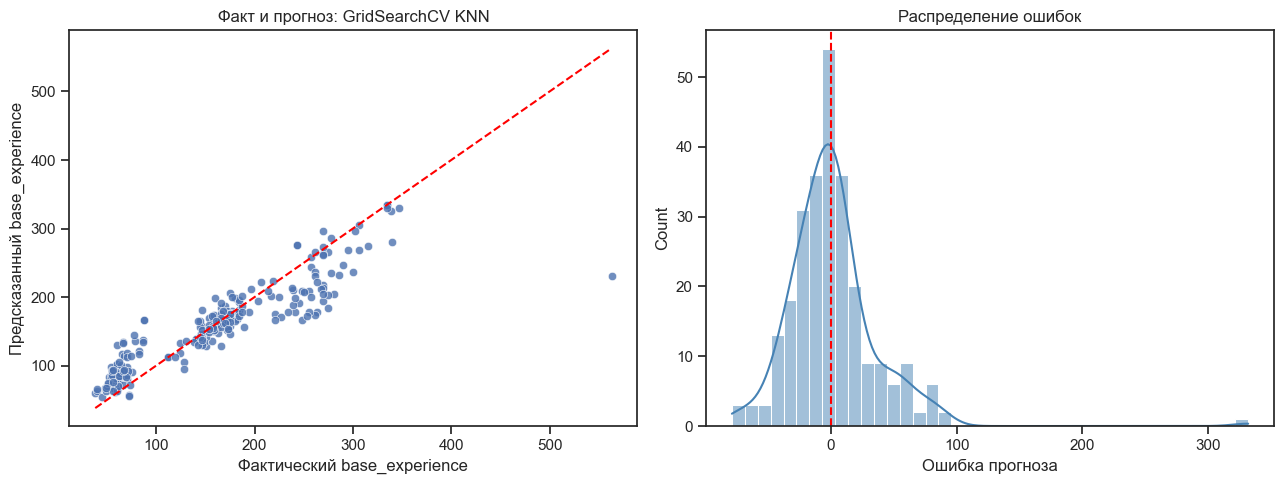

In [10]:
best_model_name = comparison.iloc[0]['model']
best_predictions = prediction_by_model[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=best_predictions, ax=axes[0], alpha=0.8)
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())
axes[0].plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--')
axes[0].set_title(f'Факт и прогноз: {best_model_name}')
axes[0].set_xlabel('Фактический base_experience')
axes[0].set_ylabel('Предсказанный base_experience')

residuals = y_test - best_predictions
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Распределение ошибок')
axes[1].set_xlabel('Ошибка прогноза')

plt.tight_layout()
plt.show()

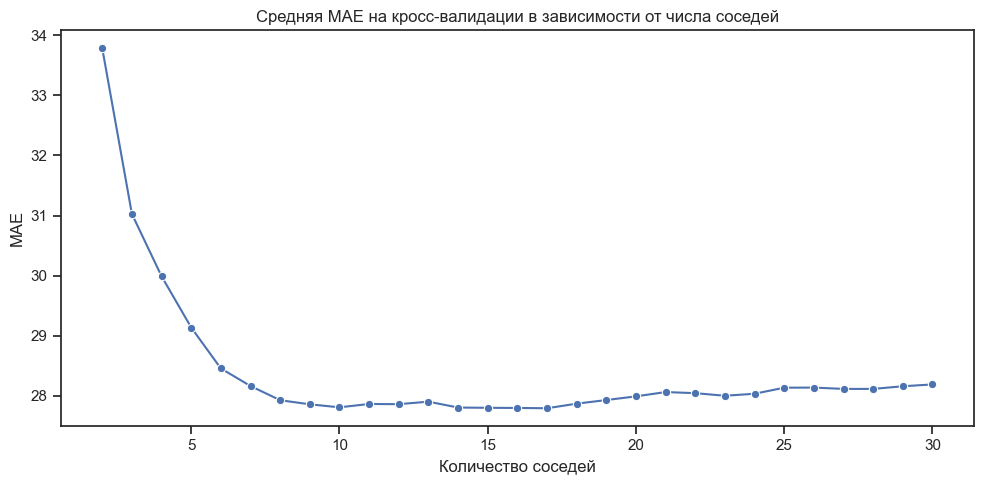

In [11]:
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results['mean_mae'] = -grid_results['mean_test_score']

mae_by_k = (
    grid_results
    .groupby('param_knn__n_neighbors', as_index=False)['mean_mae']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=mae_by_k, x='param_knn__n_neighbors', y='mean_mae', marker='o', ax=ax)
ax.set_title('Средняя MAE на кросс-валидации в зависимости от числа соседей')
ax.set_xlabel('Количество соседей')
ax.set_ylabel('MAE')
plt.tight_layout()
plt.show()

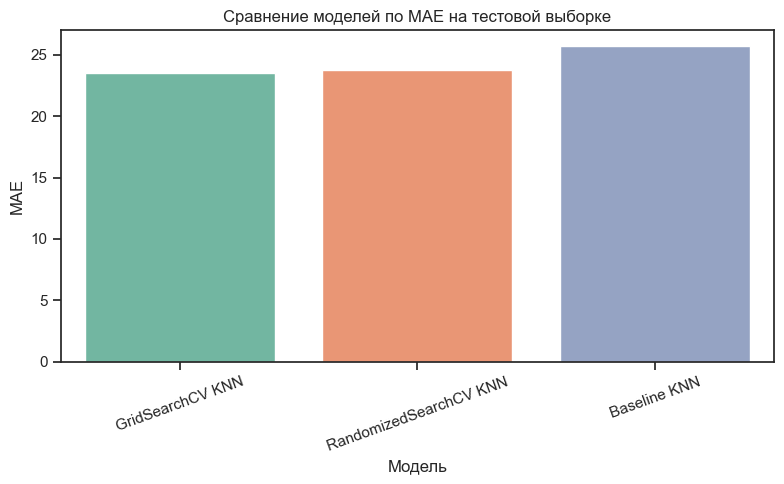

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=comparison, x='model', y='MAE', palette='Set2', ax=ax)
ax.set_title('Сравнение моделей по MAE на тестовой выборке')
ax.set_xlabel('Модель')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', labelrotation=20)
plt.tight_layout()
plt.show()

## Выводы

В работе была решена задача регрессии для прогноза `base_experience` Pokémon. Для построения признаков использовались две таблицы: основная таблица с характеристиками Pokémon и таблица взаимодействий типов.

Основные этапы работы:

- загружены и изучены данные из `pokemon_complete.csv` и `pokemon_types.csv`;
- на основе таблицы типов созданы дополнительные числовые признаки, описывающие атакующие и защитные свойства типа;
- подготовлены числовые и категориальные признаки;
- выполнено разбиение на обучающую и тестовую выборки;
- построена базовая модель `KNeighborsRegressor`;
- выполнен подбор гиперпараметров с помощью `GridSearchCV` и `RandomizedSearchCV`;
- модели сравнены по метрикам `MAE`, `RMSE` и `R2`.

Метод ближайших соседей чувствителен к масштабу признаков, поэтому числовые признаки были стандартизированы. Категориальные признаки были закодированы с помощью `OneHotEncoder`. Лучшей считается модель с минимальным значением `MAE` на тестовой выборке.